In [ ]:
!pip install transformers datasets torch scikit-learn scikit-multilearn

## Imports

In [ ]:
import torch
from torch.utils.data import Dataset
from sklearn.metrics import classification_report, hamming_loss, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from skmultilearn.model_selection import IterativeStratification
from multilabel_utils import create_fixed_splits, MultiLabelDataset, compute_metrics, train_transformer_model, run_model_experiments

## Model Names and Labels

In [ ]:
# List of Hugging Face model identifiers to evaluate
model_names = [
    "bert-base-cased",
    "snowood1/ConfliBERT-scr-cased",
    "FacebookAI/roberta-base",
    "distilbert-base-cased",
    "xlnet-base-cased",
    "google/electra-base-discriminator"
]

# Mapping from model name to human-readable label
model_labels = {
    "bert-base-cased": "BERT",
    "snowood1/ConfliBERT-scr-cased": "ConfliBERT",
    "FacebookAI/roberta-base": "RoBERTa",
    "distilbert-base-cased": "DistilBERT",
    "xlnet-base-cased": "XLNet",
    "google/electra-base-discriminator": "ELECTRA"
}

# Read From Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/colab/satp-data/action_type.csv')

data.head()

# Read from GitHub

In [ ]:
import pandas as pd

# Corrected URL to access the raw CSV data
url = 'https://raw.githubusercontent.com/eteitelbaum/code-satp/main/data/action_type.csv'

try:
    data = pd.read_csv(url)
    print(data.head())
except Exception as e:
    print(f"Error loading CSV from URL: {e}")

## Create Training, Validation and Test Sets

In [10]:
# Define your multi-label target columns
stratify_cols = [  # replace with actual label columns
    "armed_assault", "arrest", "bombing", "infrastructure",
    "surrender", "seizure", "abduction"
]

# Create fixed splits (once!)
df_train_pool, df_val, df_test = create_fixed_splits(
    df_full=data,
    stratify_cols=stratify_cols,
    test_size=0.1,
    val_size=0.111  # ~10% of original
)

### Verify Size of Training, Test and Validation Sets

In [11]:
print("Total rows:", len(data))
print("Test set:", len(df_test))
print("Training pool:", len(df_train_pool))
print("Validation set:", len(df_val))

Total rows: 9921
Test set: 972
Training pool: 7955
Validation set: 994


### Summarize Support Across Three Sets

In [ ]:
print(df_train_pool[stratify_cols].sum())
print(df_val[stratify_cols].sum())
print(df_test[stratify_cols].sum())


## Run the Models

In [ ]:
test_results_df, test_predictions_df = run_model_experiments(
    df_train_pool,
    df_val,
    df_test,
    stratify_cols=stratify_cols,
    output_csv="test_summary.csv",
    predictions_csv="test_predictions.csv",
    model_names=model_names,
    model_labels=model_labels
)

## Commit Results to GitHub

In [ ]:
# commit csv to github using python

from github import Github
import pandas as pd
import os

# Replace with your GitHub personal access token
g = Github("your_github_access_token")

# Replace with your repository name and owner
repo = g.get_user("your_github_username").get_repo("your_repository_name")

# Specify the path to the CSV file in your Colab environment
csv_file_path = "experiment_results.csv"

# Check if the file exists
if not os.path.exists(csv_file_path):
    print(f"Error: CSV file '{csv_file_path}' not found.")
else:
    # Create a file object and commit
    try:
        with open(csv_file_path, 'rb') as file_obj:
            contents = repo.create_file(
                path="experiment_results.csv",  # Specify the path in your repository
                message="Committing CSV file from Colab",
                content=file_obj.read(),
                branch="main"  # Replace with your branch name
            )
        print("CSV file successfully committed to GitHub!")
    except Exception as e:
        print(f"Error committing CSV file to GitHub: {e}")


## In Case of Drive Mounting Error

In [16]:
import shutil
shutil.rmtree('/content/drive', ignore_errors=True)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Save to Disc

In [ ]:
import os


def save_to_drive(df, filename, folder_name="actiontype"):
    base_path = "/content/drive/MyDrive/colab/satp-results/"
    drive_path = os.path.join(base_path, folder_name)

    # Create the folder if it doesn't exist
    if not os.path.exists(drive_path):
        os.makedirs(drive_path)

    filepath = os.path.join(drive_path, filename)
    df.to_csv(filepath, index=False)
    print(f"✅ DataFrame saved to: {filepath}")

save_to_drive(test_results_df, "actiontype_test1_summary.csv")
save_to_drive(test_predictions_df, "actiontype_test1_predictions.csv")

In [ ]:
!ls "/content/drive/MyDrive/colab/satp-results/actiontype"

## Preliminary Analysis

In [20]:
#mount drive
#from google.colab import drive
#drive.mount('/content/drive')

#read csv from drive
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/colab/satp-results/actiontype/actiontype_test1_summary.csv')

### F1 Micro

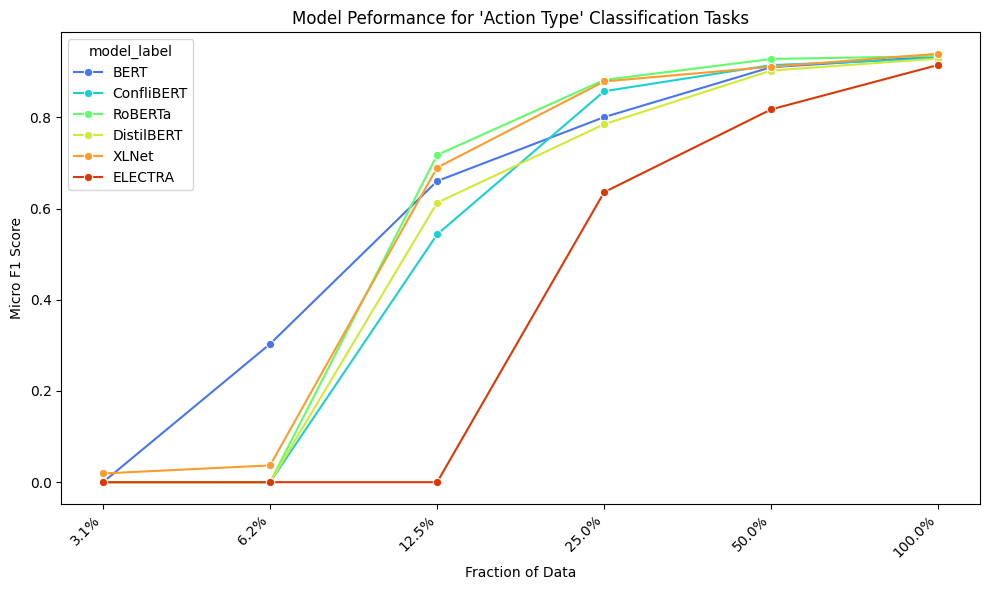

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="fraction_label",
    y="eval_micro avg_f1-score",
    hue="model_label",
    marker="o",
    palette="turbo"
    )

# Customize the plot
plt.xlabel("Fraction of Data")
plt.ylabel("Micro F1 Score")
plt.title("Model Peformance for 'Action Type' Classification Tasks")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

### Heatmap of individual labels

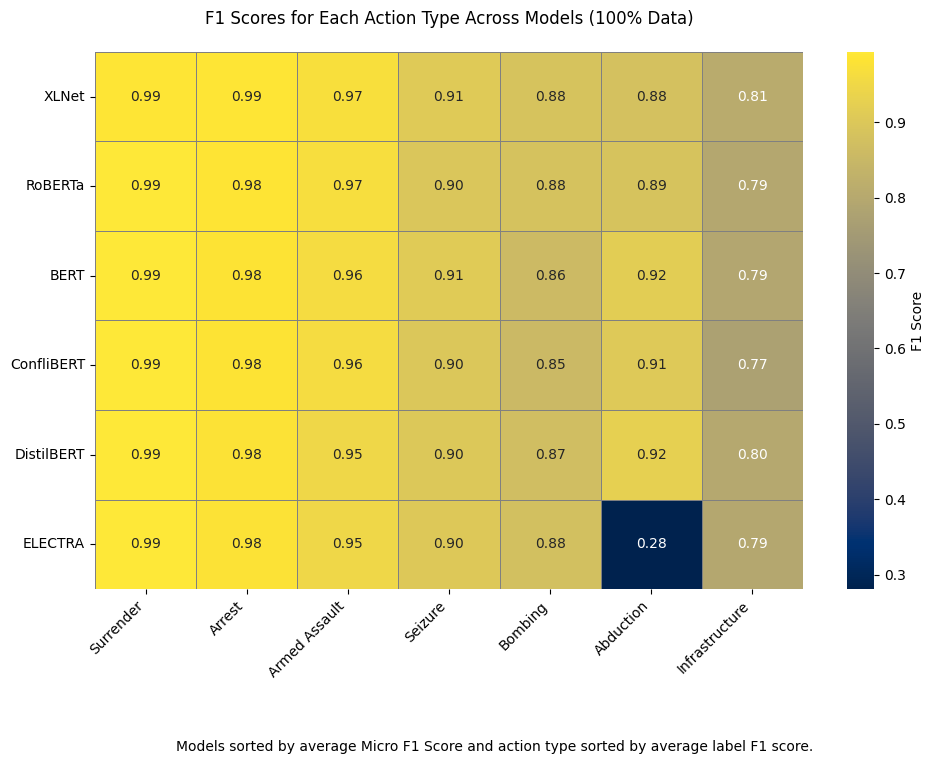

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the dataset for models trained on 100% of the data
df_100 = df[df["fraction_label"] == "100.0%"]

# Extract F1-score columns related to specific labels (excluding averages)
label_f1_columns = [col for col in df_100.columns if col.startswith("eval_") and "_f1-score" in col and "avg" not in col]

# Select only the relevant columns along with the model label
df_f1_100 = df_100[["model_label"] + label_f1_columns]

# Rename "ConfliBERT-scr-cased" to "ConfliBERT" for clarity
#df_f1_100["model_label"] = df_f1_100["model_label"].replace({"ConfliBERT-scr-cased": "ConfliBERT"})

# Convert data to long format for heatmap visualization
df_f1_melted_100 = df_f1_100.melt(id_vars=["model_label"], var_name="Label", value_name="F1 Score")

# Clean label names (remove "eval_" prefix and "_f1-score" suffix for readability)
df_f1_melted_100["Label"] = df_f1_melted_100["Label"].str.replace("eval_", "").str.replace("_f1-score", "").str.replace("_", " ").str.title()

# Pivot the table so that models are on the y-axis and event types on the x-axis
df_f1_pivot_100 = df_f1_melted_100.pivot(index="model_label", columns="Label", values="F1 Score")

# Remove "Incident Summary" if it exists
df_f1_pivot_100 = df_f1_pivot_100.drop(columns="Incident Summary", errors="ignore")

# Sort event types (columns) by their average F1 score across models (descending order)
event_order = df_f1_pivot_100.mean().sort_values(ascending=False).index
df_f1_pivot_100 = df_f1_pivot_100[event_order]

# Sort models (rows) by their Micro F1 score (descending order) while ensuring all models are included
df_model_avg_f1 = df_100.set_index("model_label")["eval_micro avg_f1-score"].sort_values(ascending=False)
model_order = df_model_avg_f1.index
df_f1_pivot_100 = df_f1_pivot_100.loc[model_order]

# Plot the heatmap
plt.figure(figsize=(10, 7))
ax = sns.heatmap(df_f1_pivot_100, annot=True, fmt=".2f", cmap="cividis", linewidths=0.5, linecolor="gray", cbar_kws={'label': 'F1 Score'})

# Customize the plot
ax.set_title("F1 Scores for Each Action Type Across Models (100% Data)", pad=20)

# Add a custom note
plt.figtext(0.5, -0.08,
            "Models sorted by average Micro F1 Score and action type sorted by average label F1 score.",
            ha="center", fontsize=10)

# Remove X and Y axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Move event type labels (x-axis) to the bottom
ax.xaxis.tick_bottom()
ax.xaxis.set_label_position('bottom')

# Adjust ticks
plt.xticks(rotation=45, ha="right")  # Rotate labels for readability
plt.yticks(rotation=0)

# Show the heatmap
plt.tight_layout()
plt.show()


### Model performance vs. speed

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def scatter_plot_speed_vs_accuracy(df, x_col, y_col, hue_col, size_col, title):
    """
    Creates a scatter (bubble) plot with customizable x and y axes.

    Parameters:
    - df: DataFrame containing the data
    - x_col: Column name for the x-axis (e.g., throughput, latency)
    - y_col: Column name for the y-axis (e.g., accuracy, latency)
    - hue_col: Column name for the hue (color grouping, e.g., model name)
    - size_col: Column name for the size (bubble size, e.g., data fraction)
    - title: Custom plot title
    """

    # Initialize figure
    plt.figure(figsize=(7, 5))

    # Create scatterplot with Seaborn
    scatter = sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,   # Color by model
        size=size_col,  # Bubble size by fraction
        sizes=(20, 400),  # Min to max size of markers
        alpha=0.7,  # Partial transparency
        palette="turbo"
    )

    # Clean up axis labels: Remove "eval_" prefix if present
    x_label_cleaned = x_col.replace("eval_", "").replace("_", " ").title()
    y_label_cleaned = y_col.replace("eval_", "").replace("_", " ").title()

    # Labeling
    scatter.set_title(title)
    scatter.set_xlabel(x_label_cleaned)  # Use cleaned x-axis label
    scatter.set_ylabel(y_label_cleaned)  # Use cleaned y-axis label

    # Retrieve the current legend handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Convert column values to string for correct matching
    model_names = df[hue_col].astype(str).unique()
    fraction_values = sorted(df[size_col].astype(str).unique())

    # Filter legend items dynamically
    hue_handles = [h for h, l in zip(handles, labels) if l in model_names]
    hue_labels = [l for l in labels if l in model_names]

    size_handles = [h for h, l in zip(handles, labels) if l in fraction_values]
    size_labels = [l for l in labels if l in fraction_values]

    # Create the updated legends
    hue_legend = plt.legend(hue_handles, hue_labels, title="Model Name", loc="upper left", bbox_to_anchor=(1.05, 1))
    plt.gca().add_artist(hue_legend)  # Ensure the first legend stays

    size_legend = plt.legend(size_handles, size_labels, title="Fraction Raw", loc="lower left", bbox_to_anchor=(1.05, 0))

    # Show the plot
    plt.tight_layout()
    plt.show()


### Micro F1 vs. samples per second

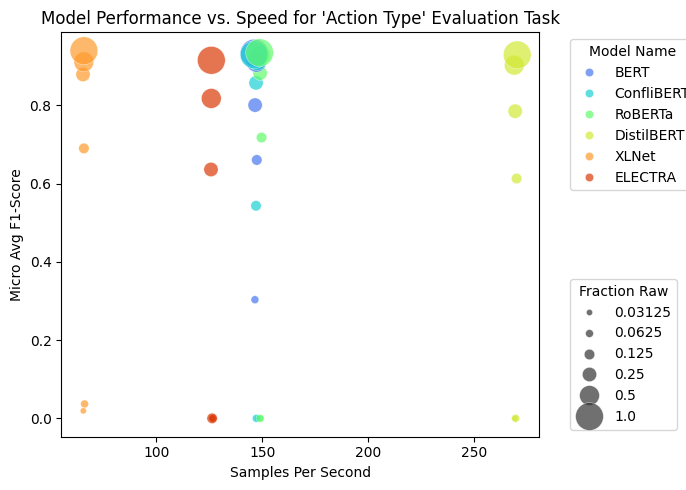

In [24]:
scatter_plot_speed_vs_accuracy(
    df=df,
    x_col="eval_samples_per_second",
    y_col="eval_micro avg_f1-score",
    hue_col="model_label",
    size_col="fraction_raw",
    title="Model Performance vs. Speed for 'Action Type' Evaluation Task"
)

In [ ]:
import nbformat
from google.colab import _message
from nbformat import from_dict

# Get current notebook content as dict
nb_json = _message.blocking_request('get_ipynb')['ipynb']

# Remove broken widgets metadata
nb_json['metadata'].pop('widgets', None)

# Convert dict to NotebookNode (needed for nbformat.write)
nb_node = from_dict(nb_json)

# Save cleaned notebook
output_path = "/content/cleaned_notebook.ipynb"
with open(output_path, "w") as f:
    nbformat.write(nb_node, f)

# Download it
from google.colab import files
files.download(output_path)
